In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys,os
import pandas as pd
import warnings
from scipy.optimize import OptimizeWarning
from scipy.optimize import curve_fit

In [2]:
def twoExp_g1_damped(xy, cs, tauS, tauT, f):
    """f=1/gamma where gamma=Cp/Cv
    cs = Cs*k: sound part
    tauS = 1/D_S q^2: sound part
    tauT = 1/D_Gamma q^2: thermo part
    """
    q = xy[:, 0]
    t = xy[:, 1]
    return f*np.exp(-t/tauS)*np.cos(cs*t) + (1-f)*np.exp(-t/tauT)


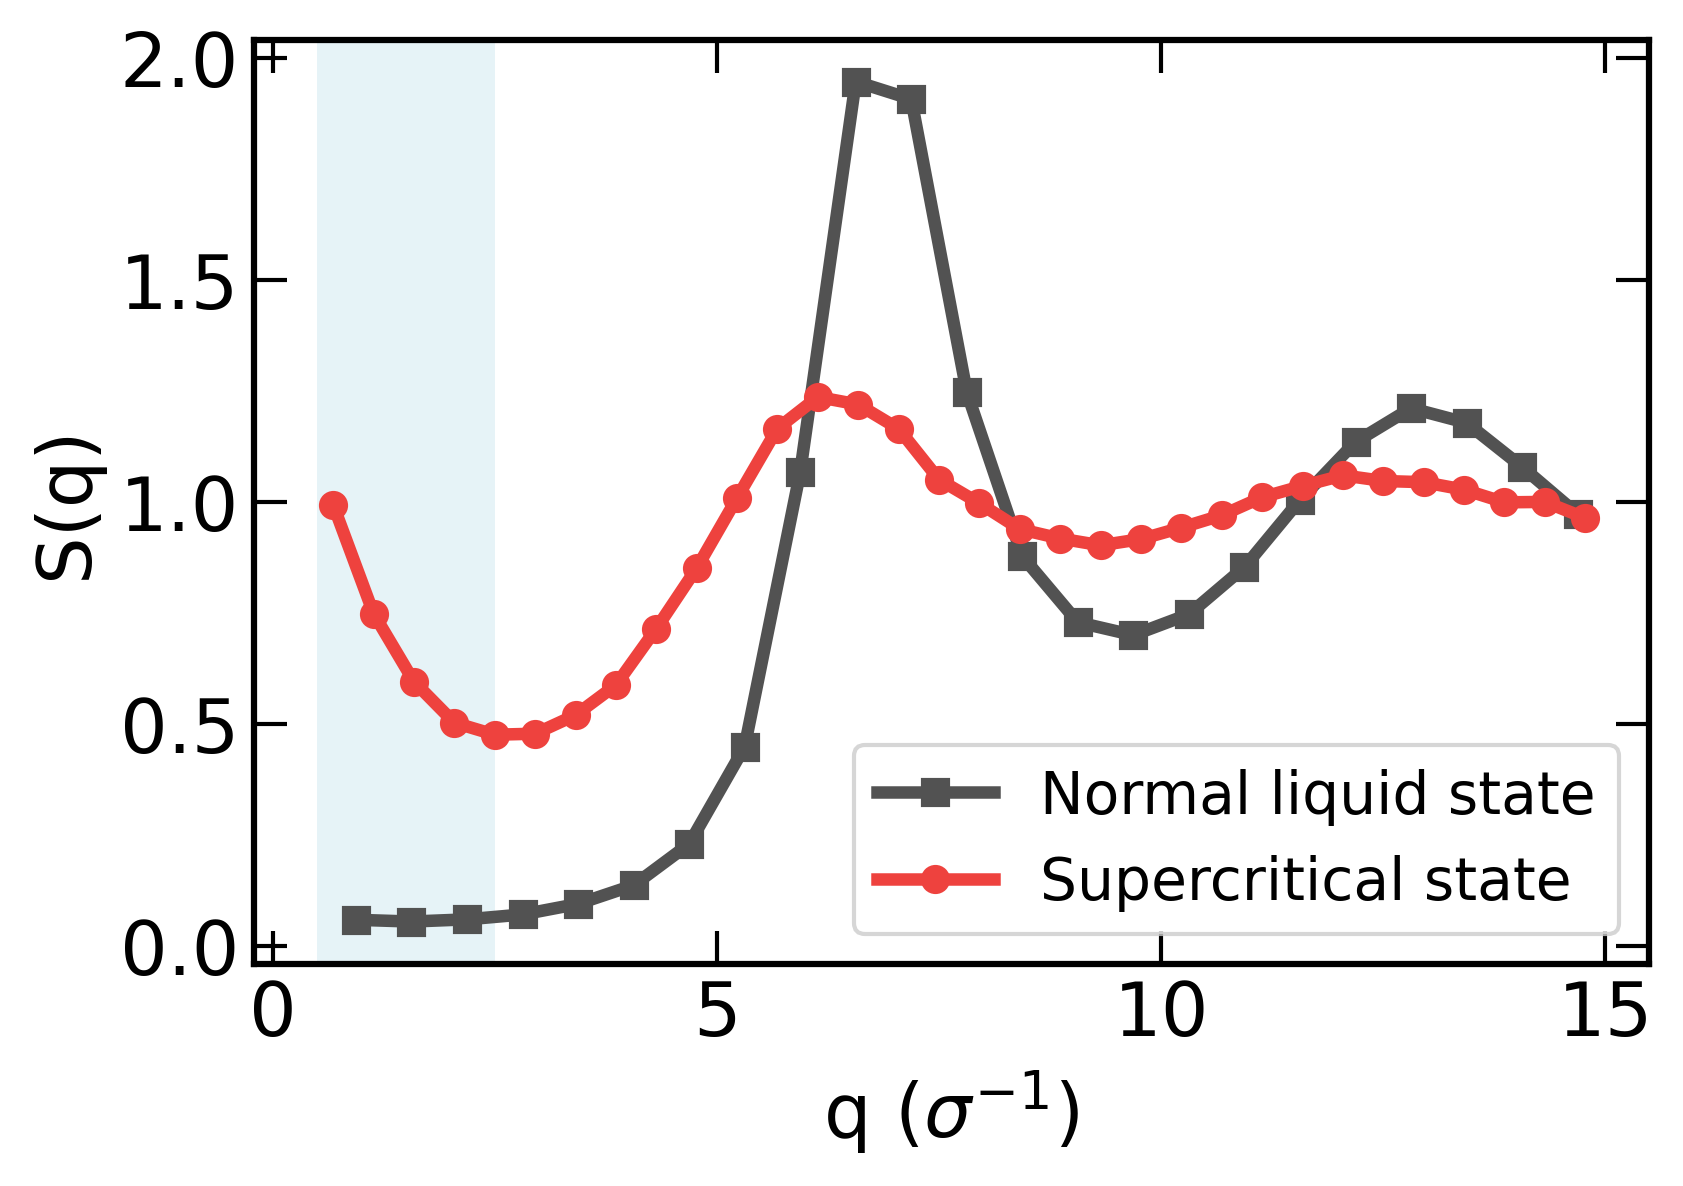

In [3]:
# fig saxs-1d comparison using the following traj

# results stored
dir_liquid = "./data/saxs-1d/liquid/"
dir_liquid_gas = "./data/saxs-1d/scf/"

start,end=1,1000
with plt.style.context('single'):
    fig,ax=plt.subplots(1,1)

    # liquid
    df_l = pd.read_csv(os.path.join(dir_liquid, "saxs_1d_analysis.csv"))
    ax.plot(df_l['q_vector'][start:end], df_l['Intensity'][start:end], label=f"Normal liquid state")

    # liquid-gas
    df_lg = pd.read_csv(os.path.join(dir_liquid_gas, "saxs_1d_analysis.csv"))
    ax.plot(df_lg['q_vector'][start:end], df_lg['Intensity'][start:end], label=f"Supercritical state")

    # show low-q
    fill_alpha=0.3
    ax.axvspan(xmin=0.5, xmax=2.5, color='lightblue', alpha=fill_alpha, edgecolor=None, lw=0)

    plt.xlabel("q "+r"$(\sigma^{-1})$")
    plt.ylabel(r"S(q)")
    plt.legend(fontsize=14)
    plt.savefig("figs/saxs1d.png")
    plt.show()

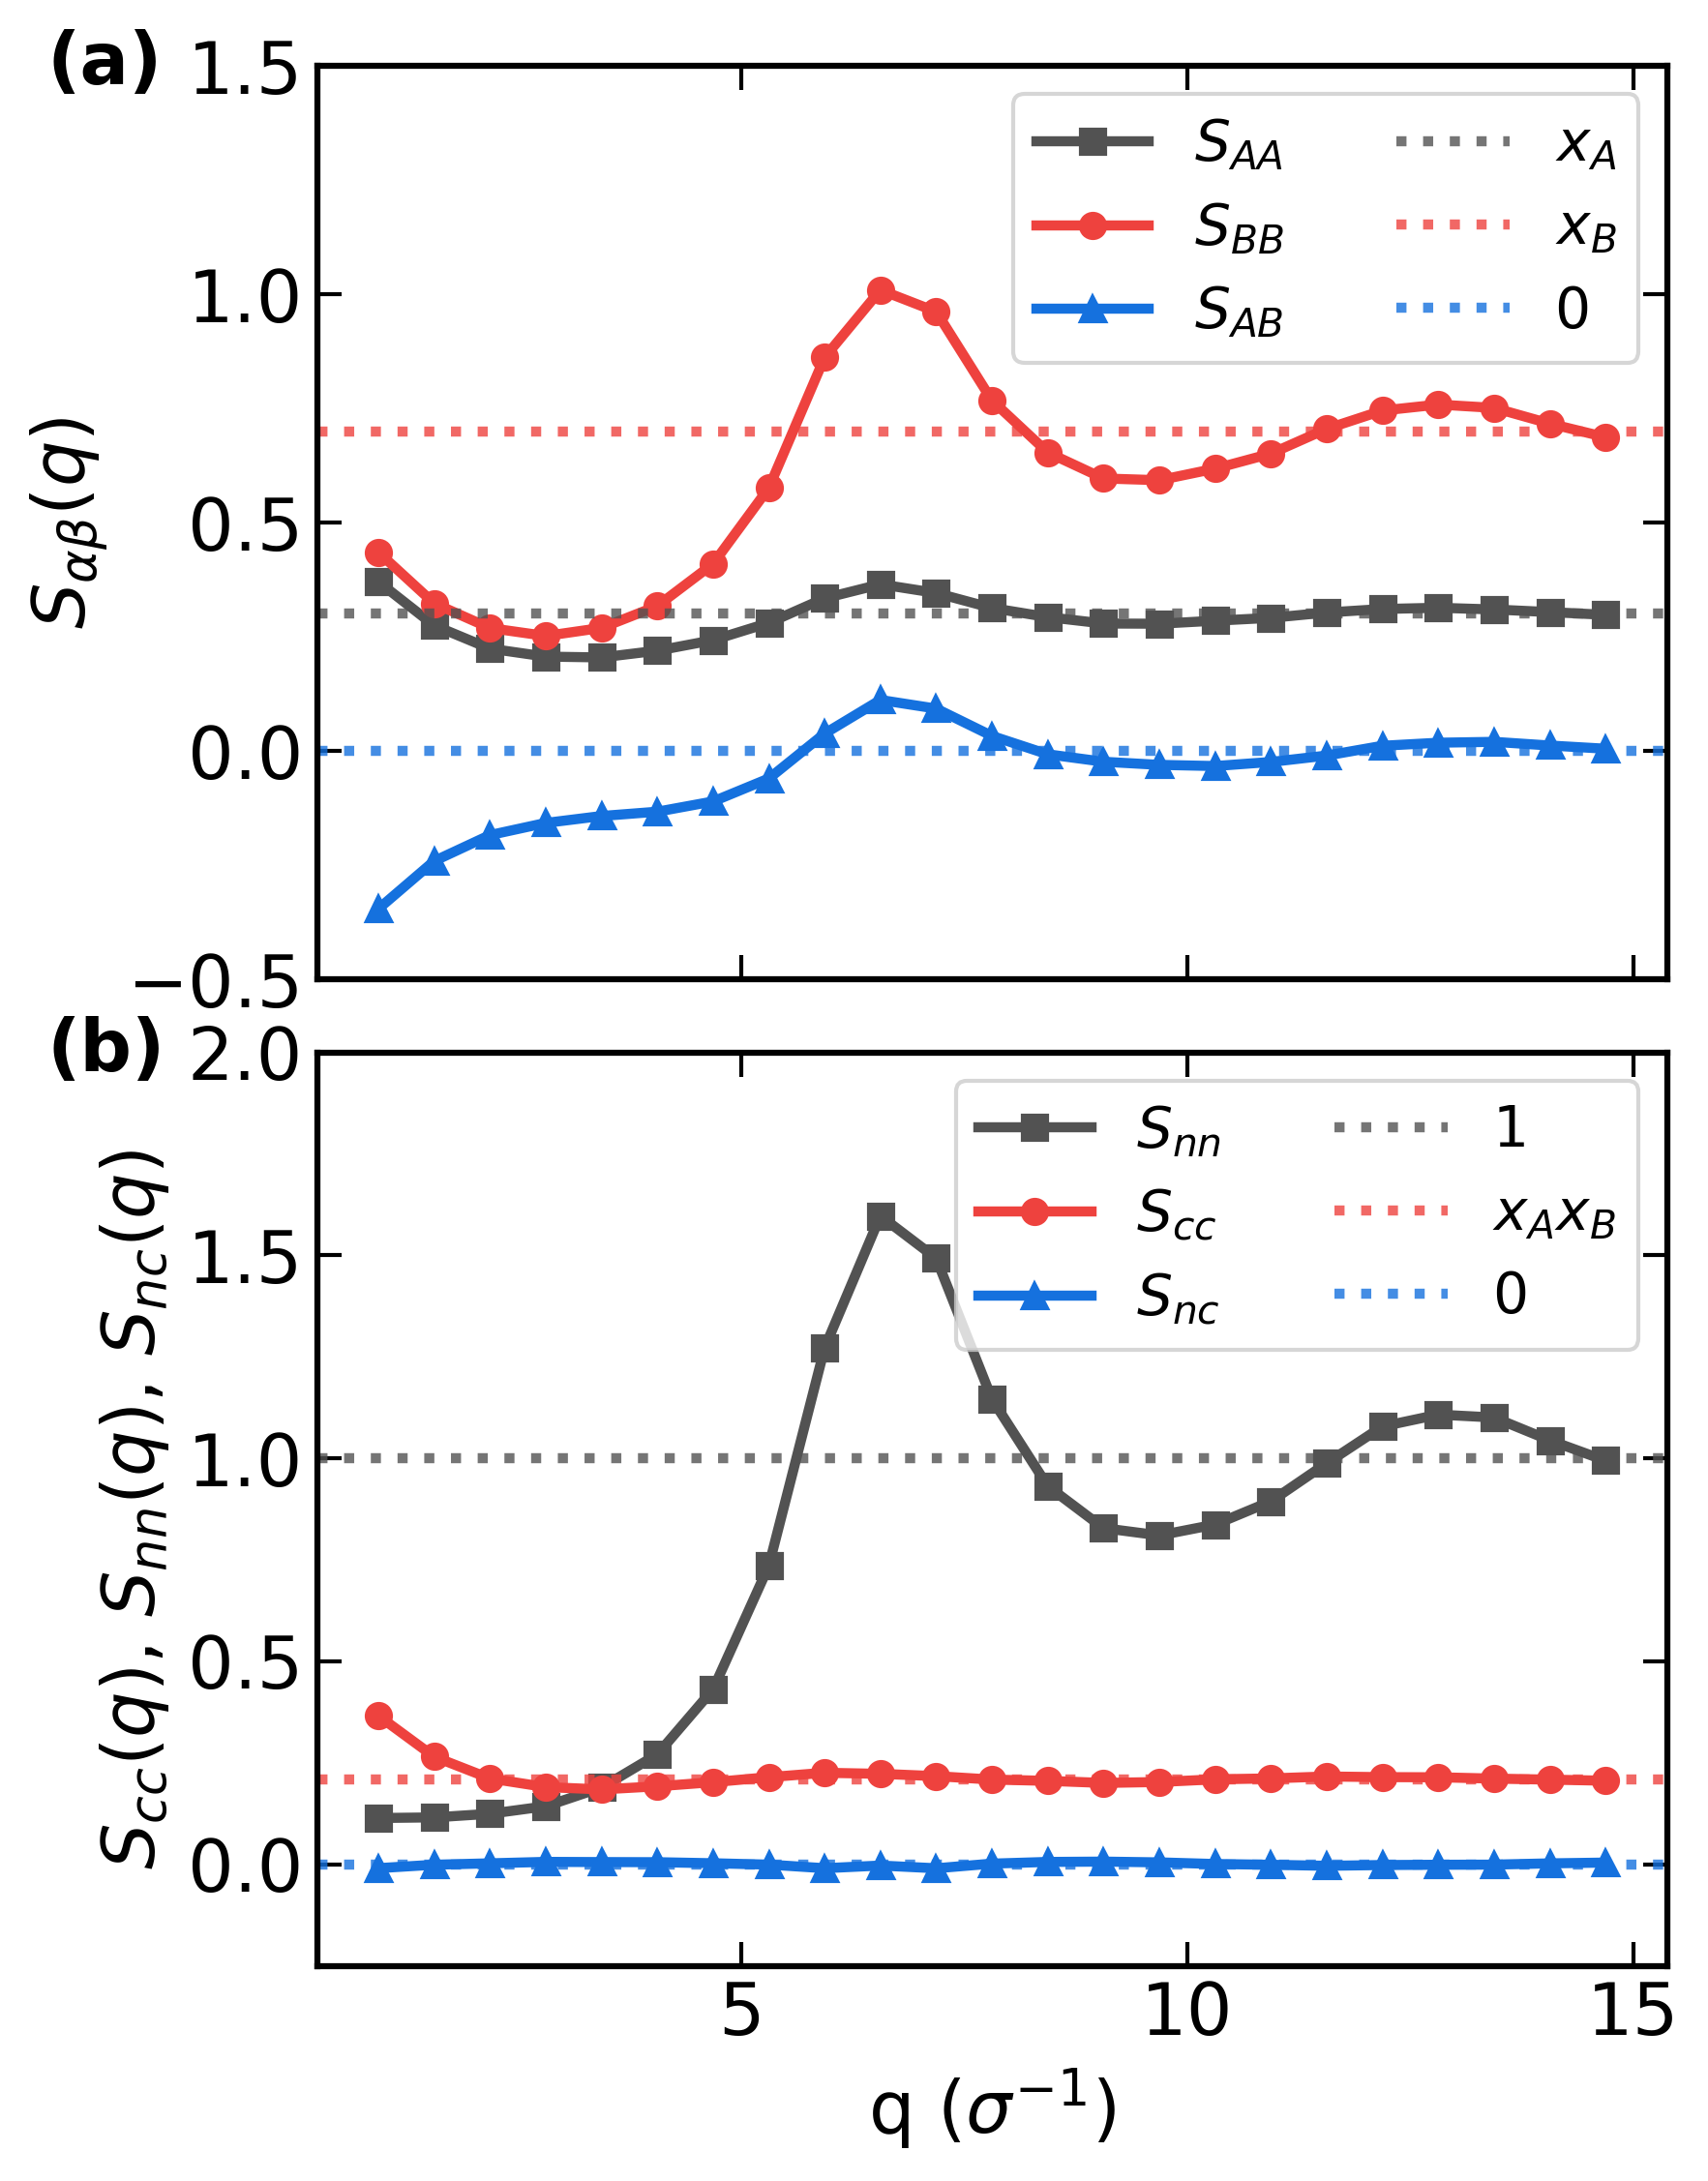

In [4]:
# fig psf of binary lj liquid

dir_binary = "./data/psf/"
df_psf = pd.read_csv(os.path.join(dir_binary, "psf_results.csv"))

startpts,endpts=1,1000
x1 = 0.3
lalpha = 0.8
with plt.style.context('double-col'):
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1)

    # ----------------------------------------------------first plot
    qr = df_psf['q']
    SAA_qt_mean = df_psf['SAA']
    SAB_qt_mean = df_psf['SAB']
    SBB_qt_mean = df_psf['SBB']
    ax1.plot(qr[startpts:endpts], SAA_qt_mean[startpts:endpts], label=r"$S_{AA}$") 
    ax1.plot(qr[startpts:endpts], SBB_qt_mean[startpts:endpts], label=r"$S_{BB}$")
    ax1.plot(qr[startpts:endpts], SAB_qt_mean[startpts:endpts], label=r"$S_{AB}$") 
    ax1.axhline(y=x1, ls=':', color='C0', label=r"$x_{A}$", alpha=lalpha)
    ax1.axhline(y=(1-x1), ls=':', color='C1', label=r"$x_{B}$", alpha=lalpha)
    ax1.axhline(y=0, ls=':', color='C2', label="0", alpha=lalpha)

    ax1.set_ylim([-0.5,1.5])
    ax1.set_ylabel(r"$S_{\alpha\beta} (q)$")
    ax1.legend(fontsize=14, ncols=2)
    ax1.set_xticklabels([])

    # ----------------------------------------------------second plot
    Snn_mean = df_psf['Snn']
    Scc_mean = df_psf['Scc']
    Snc_mean = df_psf['Snc']
    ax2.plot(qr[startpts:endpts], Snn_mean[startpts:endpts], label=r"$S_{nn}$")
    ax2.plot(qr[startpts:endpts], Scc_mean[startpts:endpts], label=r"$S_{cc}$")
    ax2.plot(qr[startpts:endpts], Snc_mean[startpts:endpts], label=r"$S_{nc}$")
    ax2.axhline(y=1, ls=':', color='C0', label=r"1", alpha=lalpha)
    ax2.axhline(y=x1*(1-x1), ls=':', color='C1', label=r"$x_{A}x_{B}$", alpha=lalpha)
    ax2.axhline(y=0, ls=':', color='C2', label="0", alpha=lalpha)

    ax2.set_ylim([-0.25,2])
    ax2.set_xlabel("q "+r"$(\sigma^{-1})$")
    ax2.set_ylabel(r"$S_{cc}(q)$"+', '+r"$S_{nn}(q)$"+', '+r"$S_{nc}(q)$")
    ax2.legend(fontsize=14, ncols=2)

    plt.subplots_adjust(hspace=0.08)
    # text
    figNOtype = "bold"
    ax1.text(-0.2,0.98,"(a)",fontweight=figNOtype, transform=ax1.transAxes)
    ax2.text(-0.2,0.98,"(b)",fontweight=figNOtype, transform=ax2.transAxes)

    plt.savefig("figs/psf.png")
    plt.show()

In [5]:
# fig isf/dsf for a unary LJ liquids

dir_isf = "./data/isf_dsf/"
q = np.load(os.path.join(dir_isf, "q.npy"))
print(q.shape)
fqt = np.load(os.path.join(dir_isf, "Fqt.npy"))
print(fqt.shape)

omega = np.load(os.path.join(dir_isf, "w.npy"))
print(omega.shape)
sqw = np.load(os.path.join(dir_isf, "Sqw.npy"))
print(sqw.shape)

(24,)
(24, 250)
(249,)
(24, 249)


In [6]:
dt_lj = 0.01 # in tau every 10 steps with dt = 0.001 Nout=1000
time = np.arange(0,fqt.shape[1],1)*dt_lj

In [7]:
# compare with filon formula
# from dynasor

"""
This module provides an implementation of Filon's integration formula.
For information about Filon's formula, see e.g.
`Abramowitz and Stegun, Handbook of Mathematical Functions,
section 25 <http://mathworld.wolfram.com/FilonsIntegrationFormula.html>`_ or
Allen and Tildesley, *Computer Simulation of Liquids*, Appendix D :cite:`AllTil87`.

Due to the algorithm the number of time samples must be odd, i.e., `t = dt * [0, ..., 2n]`.

for some angular frequency `w`::

    integral = f(x) @ (+[b/2, g, b, ..., b, g, b/2] * cos(w x)
                       +[-a,  0, 0, ..., 0, 0, a]   * sin(w x))

or::

    integral =
    + f[0   ] * (b/2 * cos(w x[0]) - a sin(w x[0]))
    + f[1   ] * (g   * cos(w x[1]))
    + f[2   ] * (b   * cos(w x[2]))
    + ...
    + f[2n-2] * (b   * cos(w x[2n-2]))
    + f[2n-1] * (g   * cos(w x[2n-1]))
    + f[2n  ] * (b/2 * cos(w x[2n]) - a sin(w x[2n]))

"""


import numpy as np
import numba
from numpy.typing import NDArray


def fourier_cos_filon(
    f: NDArray[float],
    dt: float,
) -> tuple[NDArray[float], NDArray[float]]:
    r"""Calculates the direct Fourier cosine transform :math:`F(w)` of a
    function :math:`f(t)` using Filon's integration method.

    Parameters
    ----------
    f
        function values as a 2D array. second axis will be transformed.
        must contain an odd number of elements along second axis.
    dt
        spacing of t-axis (:math:`\Delta t`)

    Returns
    -------
        A tuple comprising `w` and `F`. `w` contains values in the interval `[0, pi/dt)`.
        The length of `w` is `f.shape[1] // 2 + 1`.
        These frequencies correspond to the frequencies from a FFT,
        `w = 2*np.pi*np.fft.rfftfreq(f.shape[1], dt)`
        `F` is the transform of `f` along the second axis,
        equivalent to `np.fft.rfft(f, axis=1).real`.

    Example
    -------
    A common use case is::

        w, F = fourier_cos_filon(f, dt)
    """

    if f.ndim != 2:
        raise ValueError('f must be 2D and last axis corresponding to integration variable')

    if f.shape[1] % 2 == 0:  # Filon only works for odd N
        raise ValueError('f must contain an odd number of elements along second axis.')

    if f.shape[1] < 2:  # Time signal must be atleast three long
        raise ValueError('f must contain atleast 3 elements along second axis.')

    w = np.linspace(0, 2 * np.pi / (2 * dt), f.shape[1])

    return w, 2 * filon_2D(f, dt)


@numba.njit(fastmath=True, parallel=True)
def filon_2D(f: NDArray[float], dt: float) -> NDArray[float]:
    """Calculates the fourier transform over the last axis using filons method"""

    N_rows, Nt = f.shape

    assert Nt % 2 == 1 and Nt > 1  # Filon only works for odd N

    dw = np.pi / ((Nt - 1) * dt)

    Nw = Nt

    filon_wr = np.zeros((Nw, N_rows), dtype=np.float64)

    for wi in numba.prange(Nw):
        w = wi * dw
        filon_wr[wi] = filon_2D_inner(f, dt, w)

    filon_wr *= dt

    return filon_wr.T.copy()


@numba.njit(fastmath=True)
def filon_2D_inner(f: NDArray[float], dt: float, w: NDArray[float]) -> NDArray[float]:
    """Calculates the transform of 1D f"""

    N_rows, Nt = f.shape

    alpha, beta, gamma = _alpha_beta_gamma_single(dt * w)

    t_arr = np.arange(Nt) * dt

    phase = np.cos(w * t_arr)  # phase = np.sin(w * t_arr)  # for sin transform

    phase[::2] *= beta  # all evens get multiplied with beta
    phase[1:-1:2] *= gamma  # all odds get multiplied with gamma

    # The enpoints (even index) get an extra factor of 1/2
    phase[0] *= 0.5
    phase[-1] *= 0.5

    # The endpoints must also get an extra term
    phase[0] -= alpha * np.sin(w * t_arr[0])  # phase[0] += alpha * np.cos(w * t_arr[0])
    phase[-1] += alpha * np.sin(w * t_arr[-1])  # phase[-1] -= alpha * np.cos(w * t_arr[-1])

    filon = np.zeros(N_rows, dtype=np.float64)

    for r in range(N_rows):
        for t in range(Nt):
            filon[r] += f[r, t] * phase[t]

    return filon


@numba.njit(fastmath=False)
def _alpha_beta_gamma_single(t: float) -> tuple[float, float, float]:
    """Calculate alpha, beta, and gamma from theta (`t`)."""

    if t == 0:
        alpha, beta, gamma = 0.0, 2/3, 4/3
    else:
        alpha = (t**2 + t * np.sin(t) * np.cos(t) - 2 * np.sin(t)**2) / t**3
        beta = 2 * (t * (1 + np.cos(t)**2) - 2 * np.sin(t) * np.cos(t)) / t**3
        gamma = 4 * (np.sin(t) - t * np.cos(t)) / t**3

    return alpha, beta, gamma

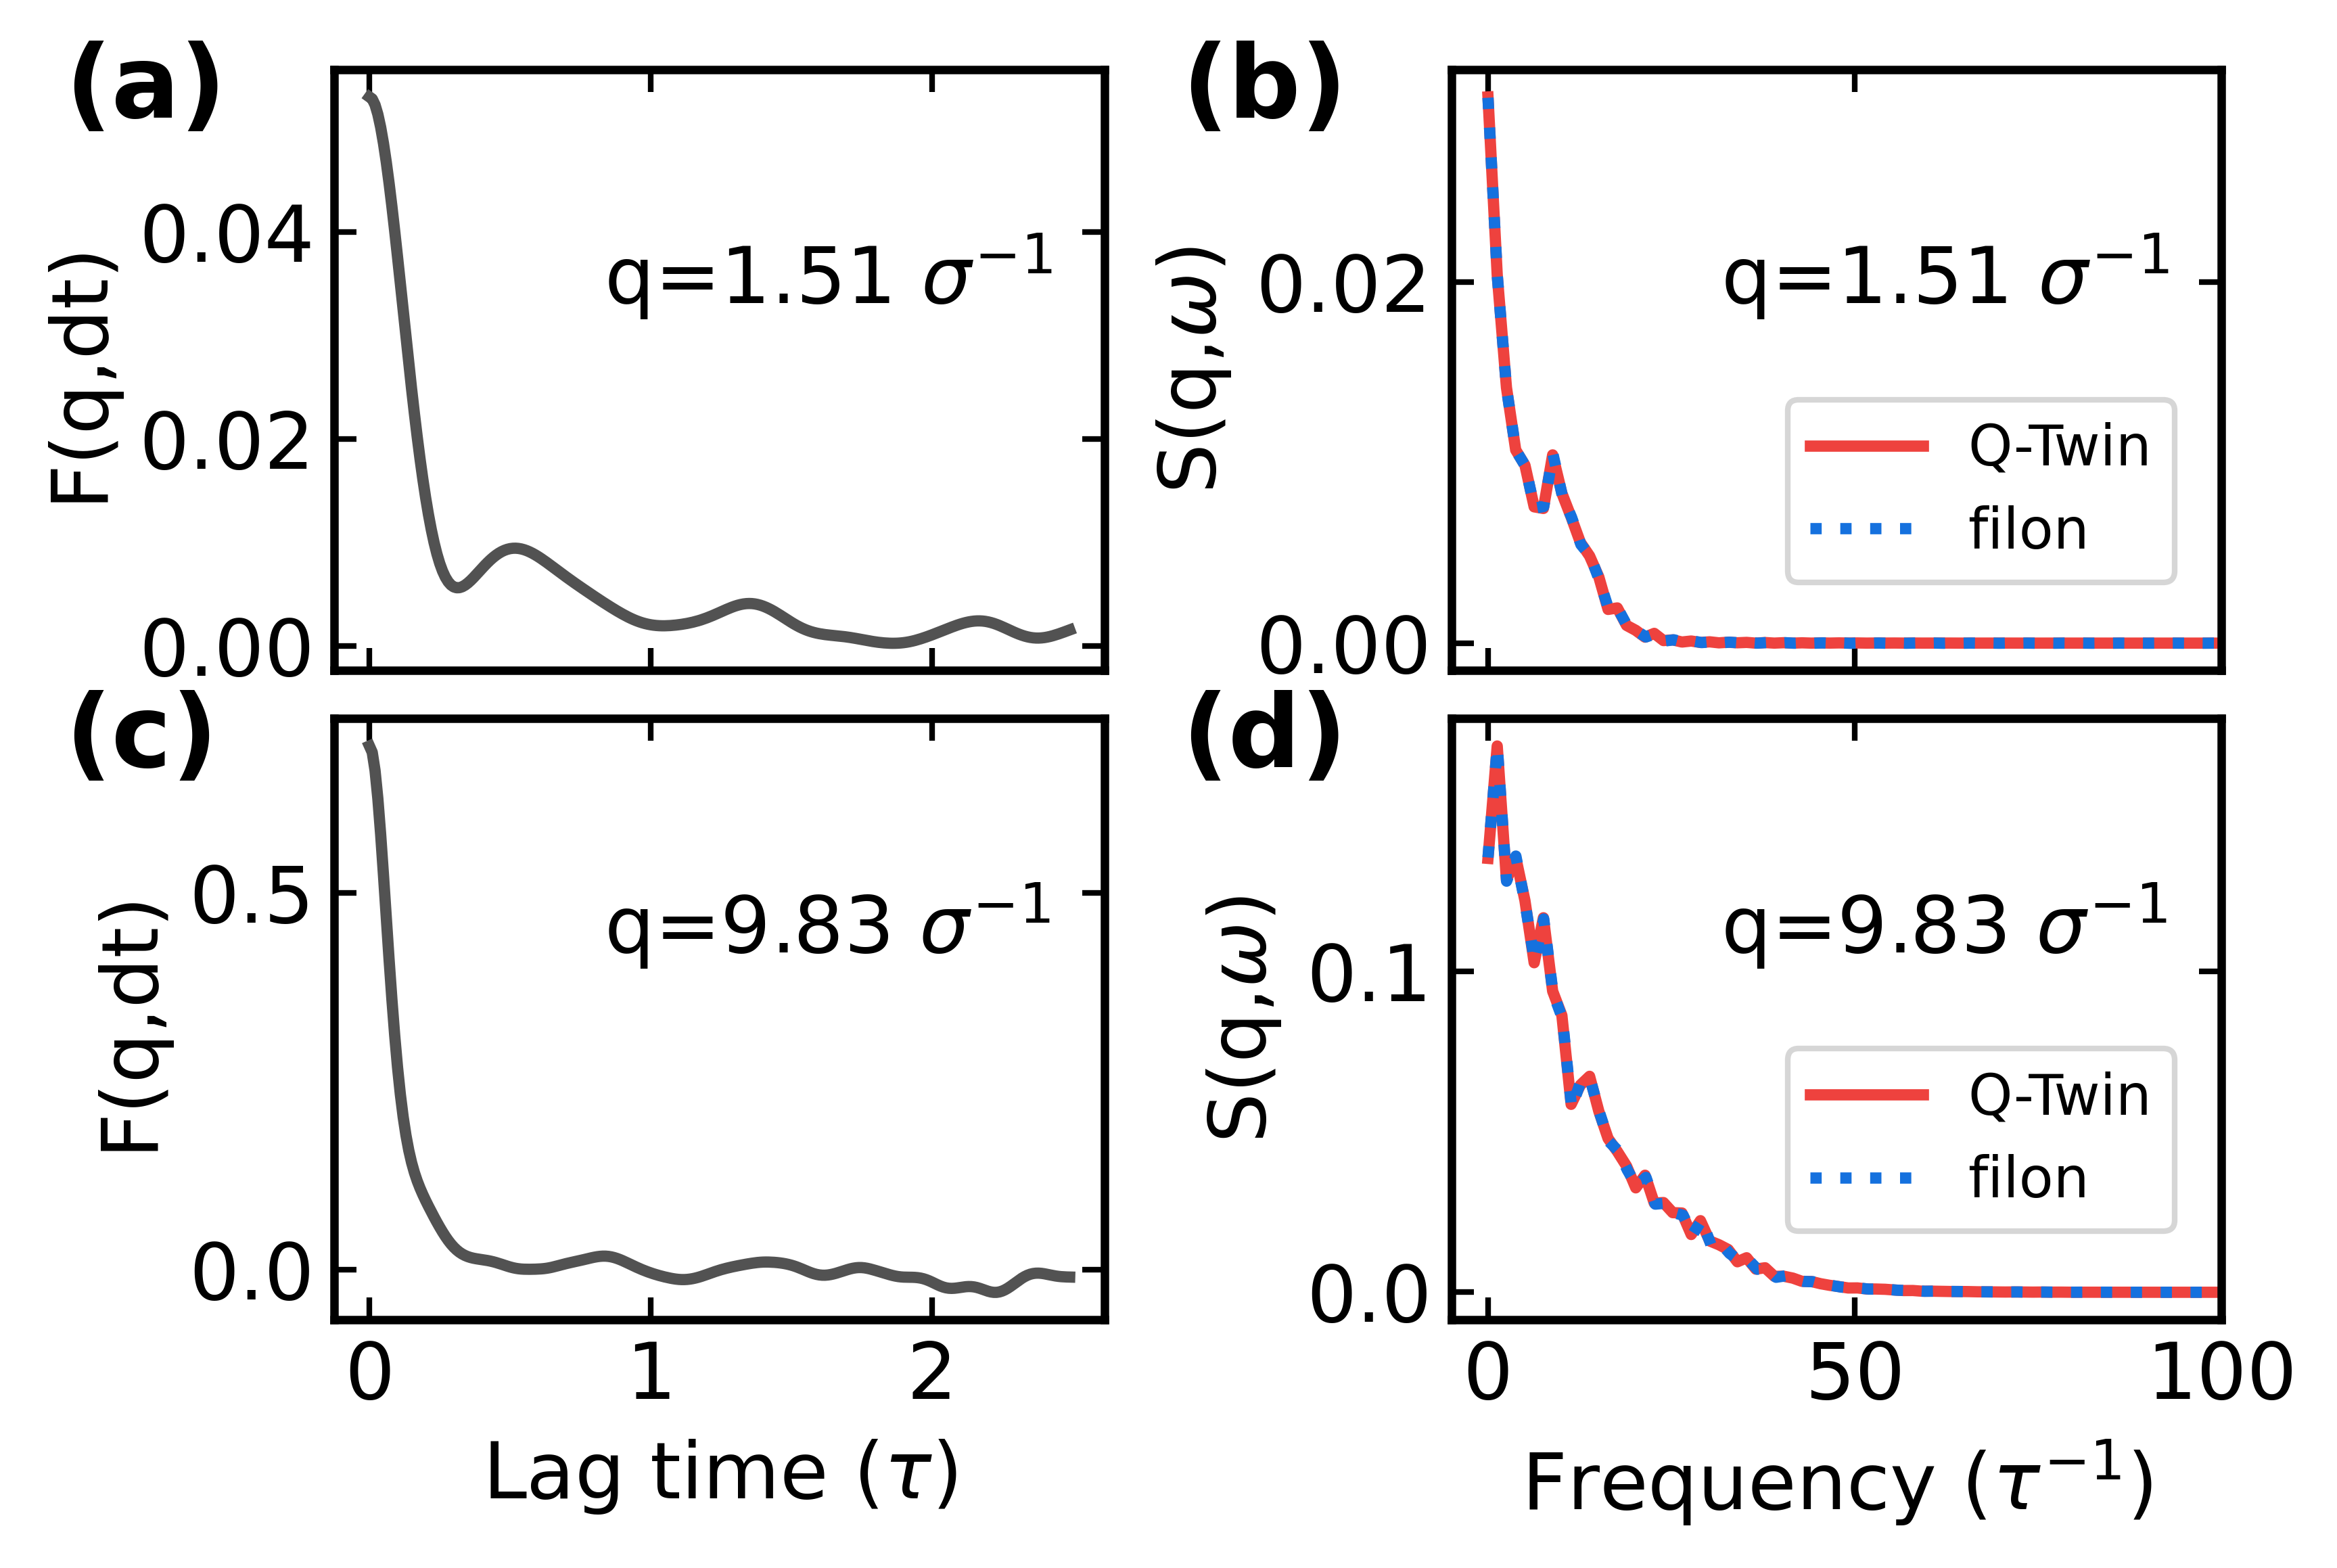

In [8]:
with plt.style.context('four'):
    fig, axes = plt.subplots(nrows=2, ncols=2)

    # two qs: small vs large
    lo_q_idx = 1
    axes[0,0].plot(time, fqt[lo_q_idx, :], '-', label=f"q={q[lo_q_idx]:.2f} "+r"$\sigma^{-1}$")
    axes[0,0].set_title(f"q={q[lo_q_idx]:.2f} "+r"$\sigma^{-1}$", pad=-2, x=0.35, y=0.6, ha='left', va='bottom', fontsize=14)
    axes[0,1].plot(omega, sqw[lo_q_idx, :], '-', color="C1", label=f"Q-Twin")
    axes[0,1].set_title(f"q={q[lo_q_idx]:.2f} "+r"$\sigma^{-1}$", pad=-2, x=0.35, y=0.6, ha='left', va='bottom', fontsize=14)
    omega1, sqw1 = fourier_cos_filon(fqt[:,:-1], dt_lj)
    axes[0,1].plot(omega1, sqw1[lo_q_idx, :], ':', color="C2", label=f"filon")

    hi_q_idx = 15
    axes[1,0].plot(time, fqt[hi_q_idx, :], '-', color="C0", label=f"q={q[hi_q_idx]:.2f} "+r"$\sigma^{-1}$")
    axes[1,0].set_title(f"q={q[hi_q_idx]:.2f} "+r"$\sigma^{-1}$", pad=-2, x=0.35, y=0.6, ha='left', va='bottom', fontsize=14)
    axes[1,1].plot(omega, sqw[hi_q_idx, :], '-', color="C1", label=f"Q-Twin")
    axes[1,1].set_title(f"q={q[hi_q_idx]:.2f} "+r"$\sigma^{-1}$", pad=-2, x=0.35, y=0.6, ha='left', va='bottom', fontsize=14)
    omega1, sqw1 = fourier_cos_filon(fqt[:,:-1], dt_lj)
    axes[1,1].plot(omega1, sqw1[hi_q_idx, :], ':', color="C2", label=f"filon")

    axes[0,0].set_xticklabels([])
    axes[0,1].set_xticklabels([])
    axes[0,1].legend(fontsize=10,loc="lower left",bbox_to_anchor=(0.4,0.1))
    axes[1,1].legend(fontsize=10,loc="lower left",bbox_to_anchor=(0.4,0.1))
    # ax1.set_xlim([-0.25,2.3])
    # for ax in axes[:, 0]:
    #     ax.legend(fontsize=12)

    for ax in axes[:,0]:        
        ax.set_ylabel(r"F(q,dt)")

    for ax in axes[:,1]:        
        ax.set_xlim([-5,100])
        ax.set_ylabel(r"S(q,$\omega$)")

    axes[1,0].set_xlabel("Lag time "+r"($\tau$)")
    axes[1,1].set_xlabel("Frequency "+r"($\tau^{-1}$)")

    # text
    figNOtype = "bold"
    for ax, ax_label in zip(axes.flatten(), ["(a)","(b)","(c)","(d)"]):
        ax.text(-0.35,0.92,ax_label,fontweight=figNOtype, transform=ax.transAxes)

    # plt.tight_layout()
    plt.subplots_adjust(hspace=0.08, wspace=0.45)
    plt.savefig("figs/isf-dsf.png")
    plt.show()

1.5112500000000002 [9.5056807  0.33315207 0.39842628 0.40026783]
9.829583333333334 [8.55096088 0.13353343 0.18138284 0.57523968]


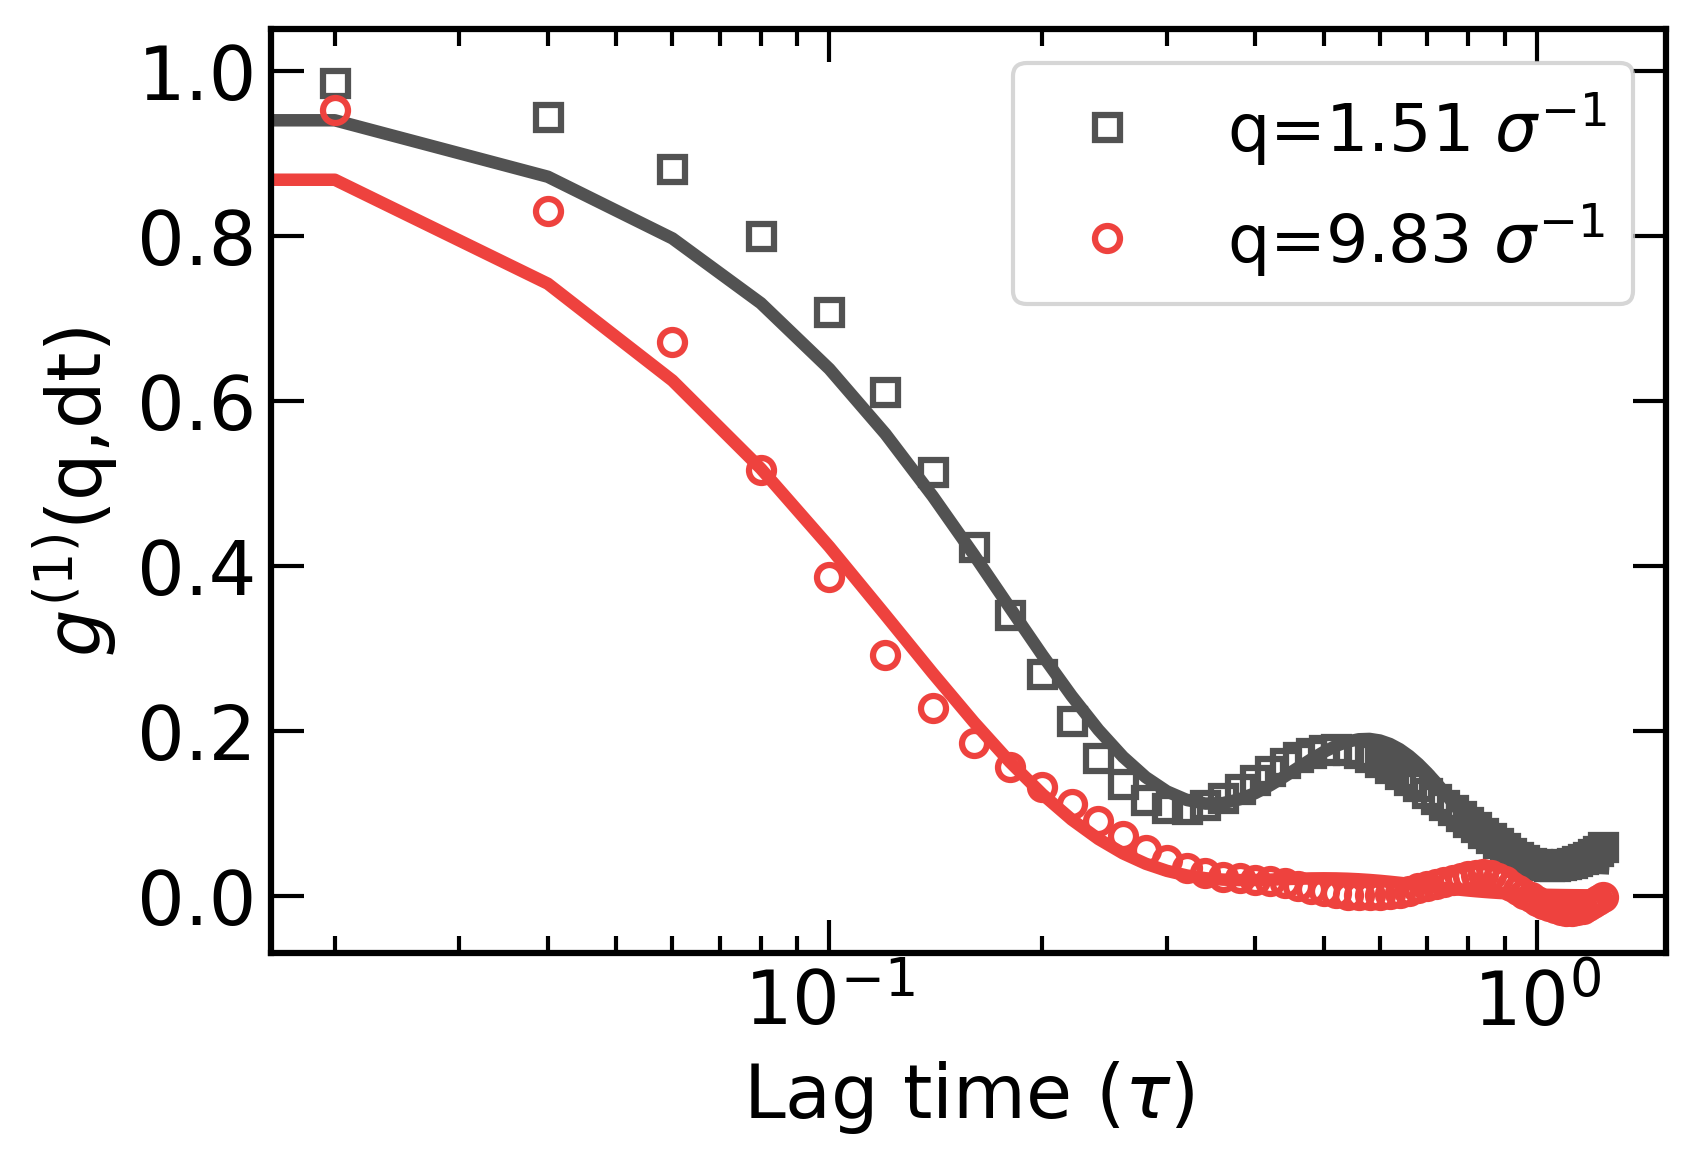

In [9]:
# fit
tstart = 0
tend = len(time)//2
tstep = 2
q_idx_list = [1, 15]
time_fit = np.linspace(time[tstart], time[tend], len(time)//2)

with plt.style.context('single'):
    for idx, lo_q_idx in enumerate(q_idx_list):
        g1_finc = fqt[lo_q_idx, :]/fqt[lo_q_idx, 0]
        plt.plot(time[tstart:tend:tstep], g1_finc[tstart:tend:tstep],ls='none',
                 color=f'C{idx}',
                 markerfacecolor='none',
                 markeredgewidth=1.5,
                 label=f"q={q[lo_q_idx]:.2f} "+r"$\sigma^{-1}$")

        with warnings.catch_warnings():
            warnings.simplefilter("error", OptimizeWarning)
            try:
                            
                im_x, im_y = np.meshgrid(qr[lo_q_idx], time[tstart:tend:tstep])
                xdata = np.c_[im_x.flatten(), im_y.flatten()]
                popt, pconv = curve_fit(twoExp_g1_damped, xdata, g1_finc[tstart:tend:tstep], 
                                        bounds=(0.0, [np.inf,np.inf,np.inf, 1.0])) # convert to ns                
                print(q[lo_q_idx], popt) # cs, tauS, tauT, f

                # im_x, im_y = np.meshgrid(qr[lo_q_idx], time_fit)
                # xdata = np.c_[im_x.flatten(), im_y.flatten()]
                # plt.plot(time_fit, twoExp_g1_damped(xdata, *popt), '-',color=f'C{idx}')
                plt.plot(time[tstart:tend:tstep], twoExp_g1_damped(xdata, *popt), '-',color=f'C{idx}')
            
            except OptimizeWarning:
                pass  

    plt.xscale('log')
    # plt.yscale('log')
    plt.xlabel("Lag time "+r"($\tau$)")
    plt.ylabel(r"$g^{(1)}$(q,dt)")
    plt.legend()
    plt.savefig("figs/g1fit.png")
    plt.show()

(1001, 193, 193)


<Figure size 2400x900 with 0 Axes>

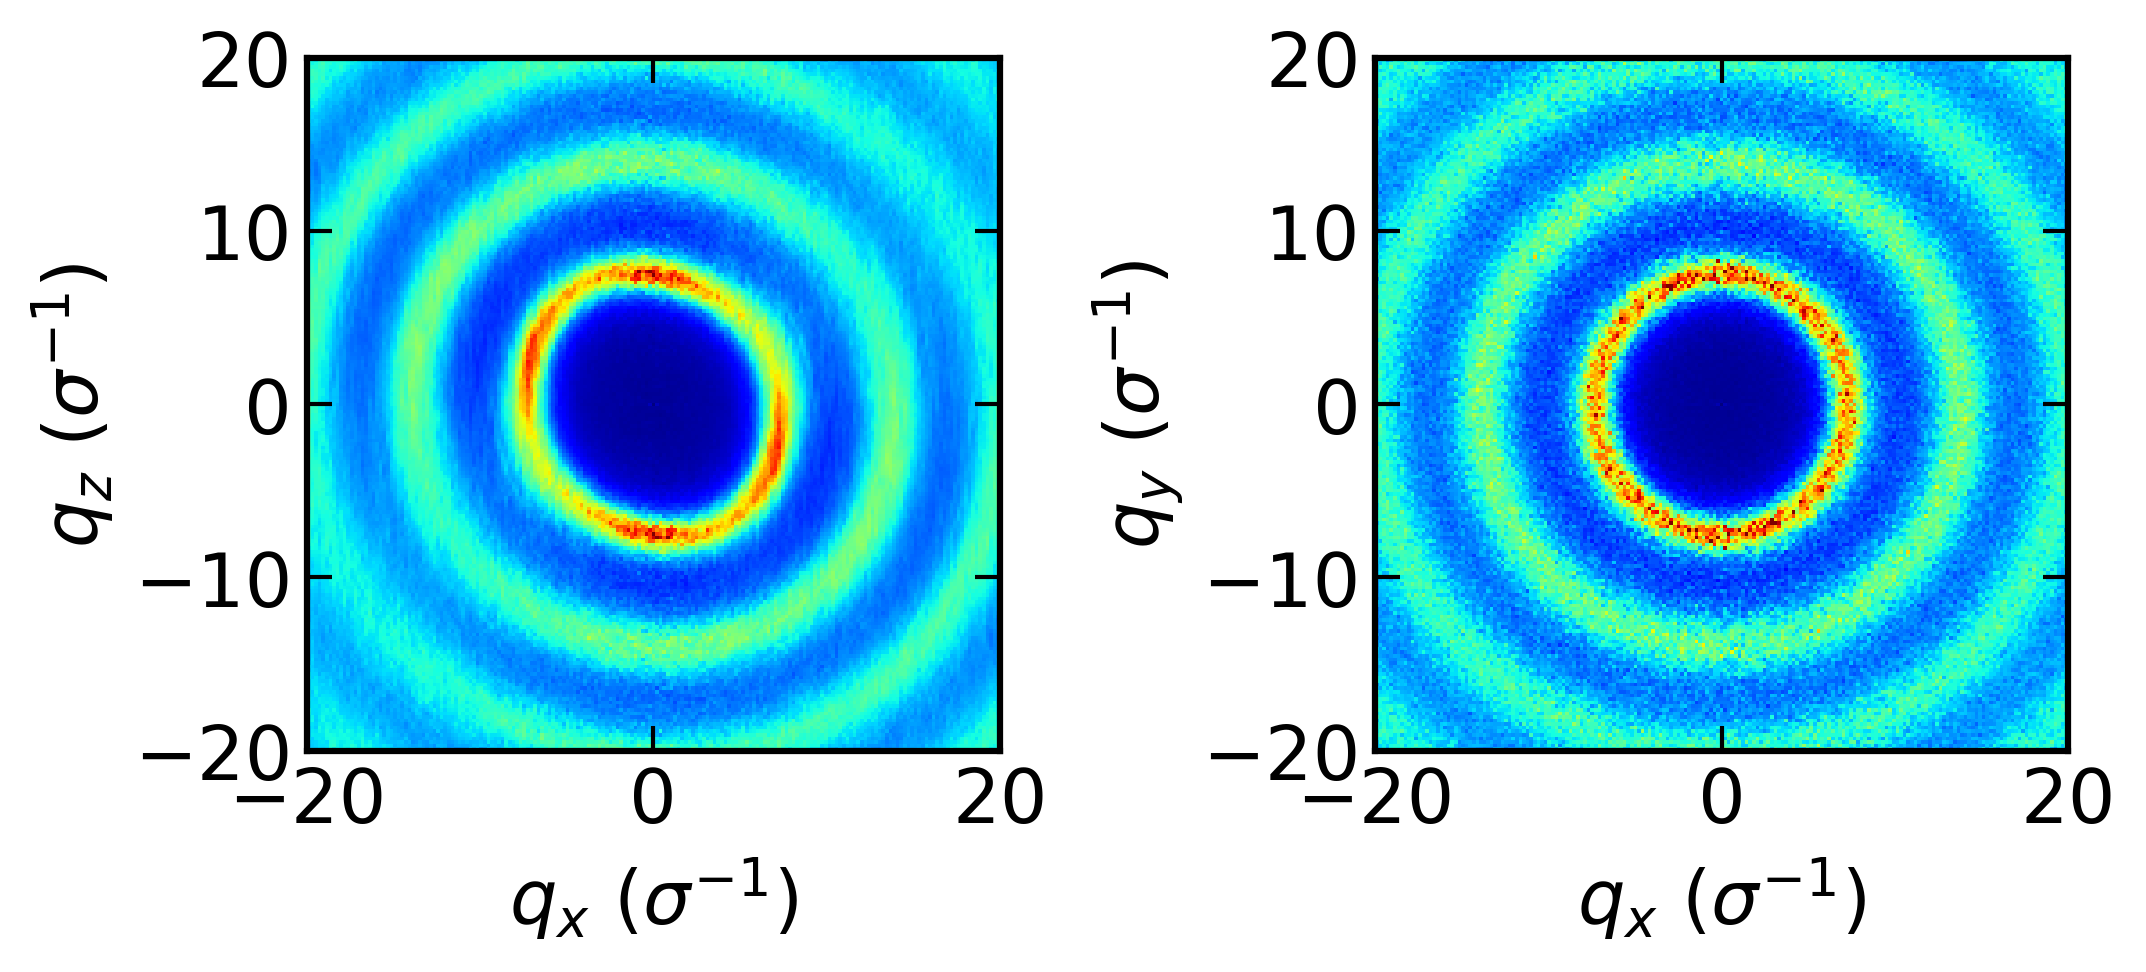

In [10]:
# fig colloids 2d scattering profile
dir_saxs2d = "./data/saxs-2d"

with plt.style.context('double-row'):
    plt.clf()
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)

    # first figure: xy
    ssf_xy_t=np.load(os.path.join(dir_saxs2d, "xy/saxs_2d.npy"))
    print(ssf_xy_t.shape)
    saxs_xy = np.mean(ssf_xy_t, axis=0)
    saxs_xy[saxs_xy.shape[0]//2,saxs_xy.shape[1]//2] = 0.0

    im = ax2.imshow(saxs_xy, 
                     interpolation='none', #'gaussian', 
                     origin='lower',
                     extent=[-20, 20, -20, 20], 
                     cmap='jet')
    im.set_clim(vmin=0.0, vmax=3.0)
    # cbar = fig.colorbar(im,ax=ax2) 

    # second figure: xz
    ssf_xz_t=np.load(os.path.join(dir_saxs2d, "xz/saxs_2d.npy"))
    saxs_xz = np.mean(ssf_xz_t, axis=0)
    saxs_xz[saxs_xz.shape[0]//2,saxs_xz.shape[1]//2] = 0.0
    im = ax1.imshow(saxs_xz, 
                     interpolation='none', #'gaussian', 
                     origin='lower',
                     extent=[-20, 20, -20, 20], 
                     cmap='jet')
    im.set_clim(vmin=0.0, vmax=3.0)
    # cbar = fig.colorbar(im,ax=ax1) 

    ax1.set_xlabel("$q_x$"+" "+r"($\sigma^{-1}$)")
    ax2.set_xlabel("$q_x$"+" "+r"($\sigma^{-1}$)")
    ax1.set_ylabel("$q_z$"+" "+r"($\sigma^{-1}$)")
    ax2.set_ylabel("$q_y$"+" "+r"($\sigma^{-1}$)")
    
    # plt.tight_layout()
    plt.subplots_adjust(wspace=0.35)
    # # text
    # figNOtype = "bold"
    # ax1.text(-0.3,0.98,"(c)",fontweight=figNOtype, transform=ax1.transAxes)
    # ax2.text(-0.3,0.98,"(d)",fontweight=figNOtype, transform=ax2.transAxes)

    plt.savefig("figs/saxs2d.png")
    plt.show()


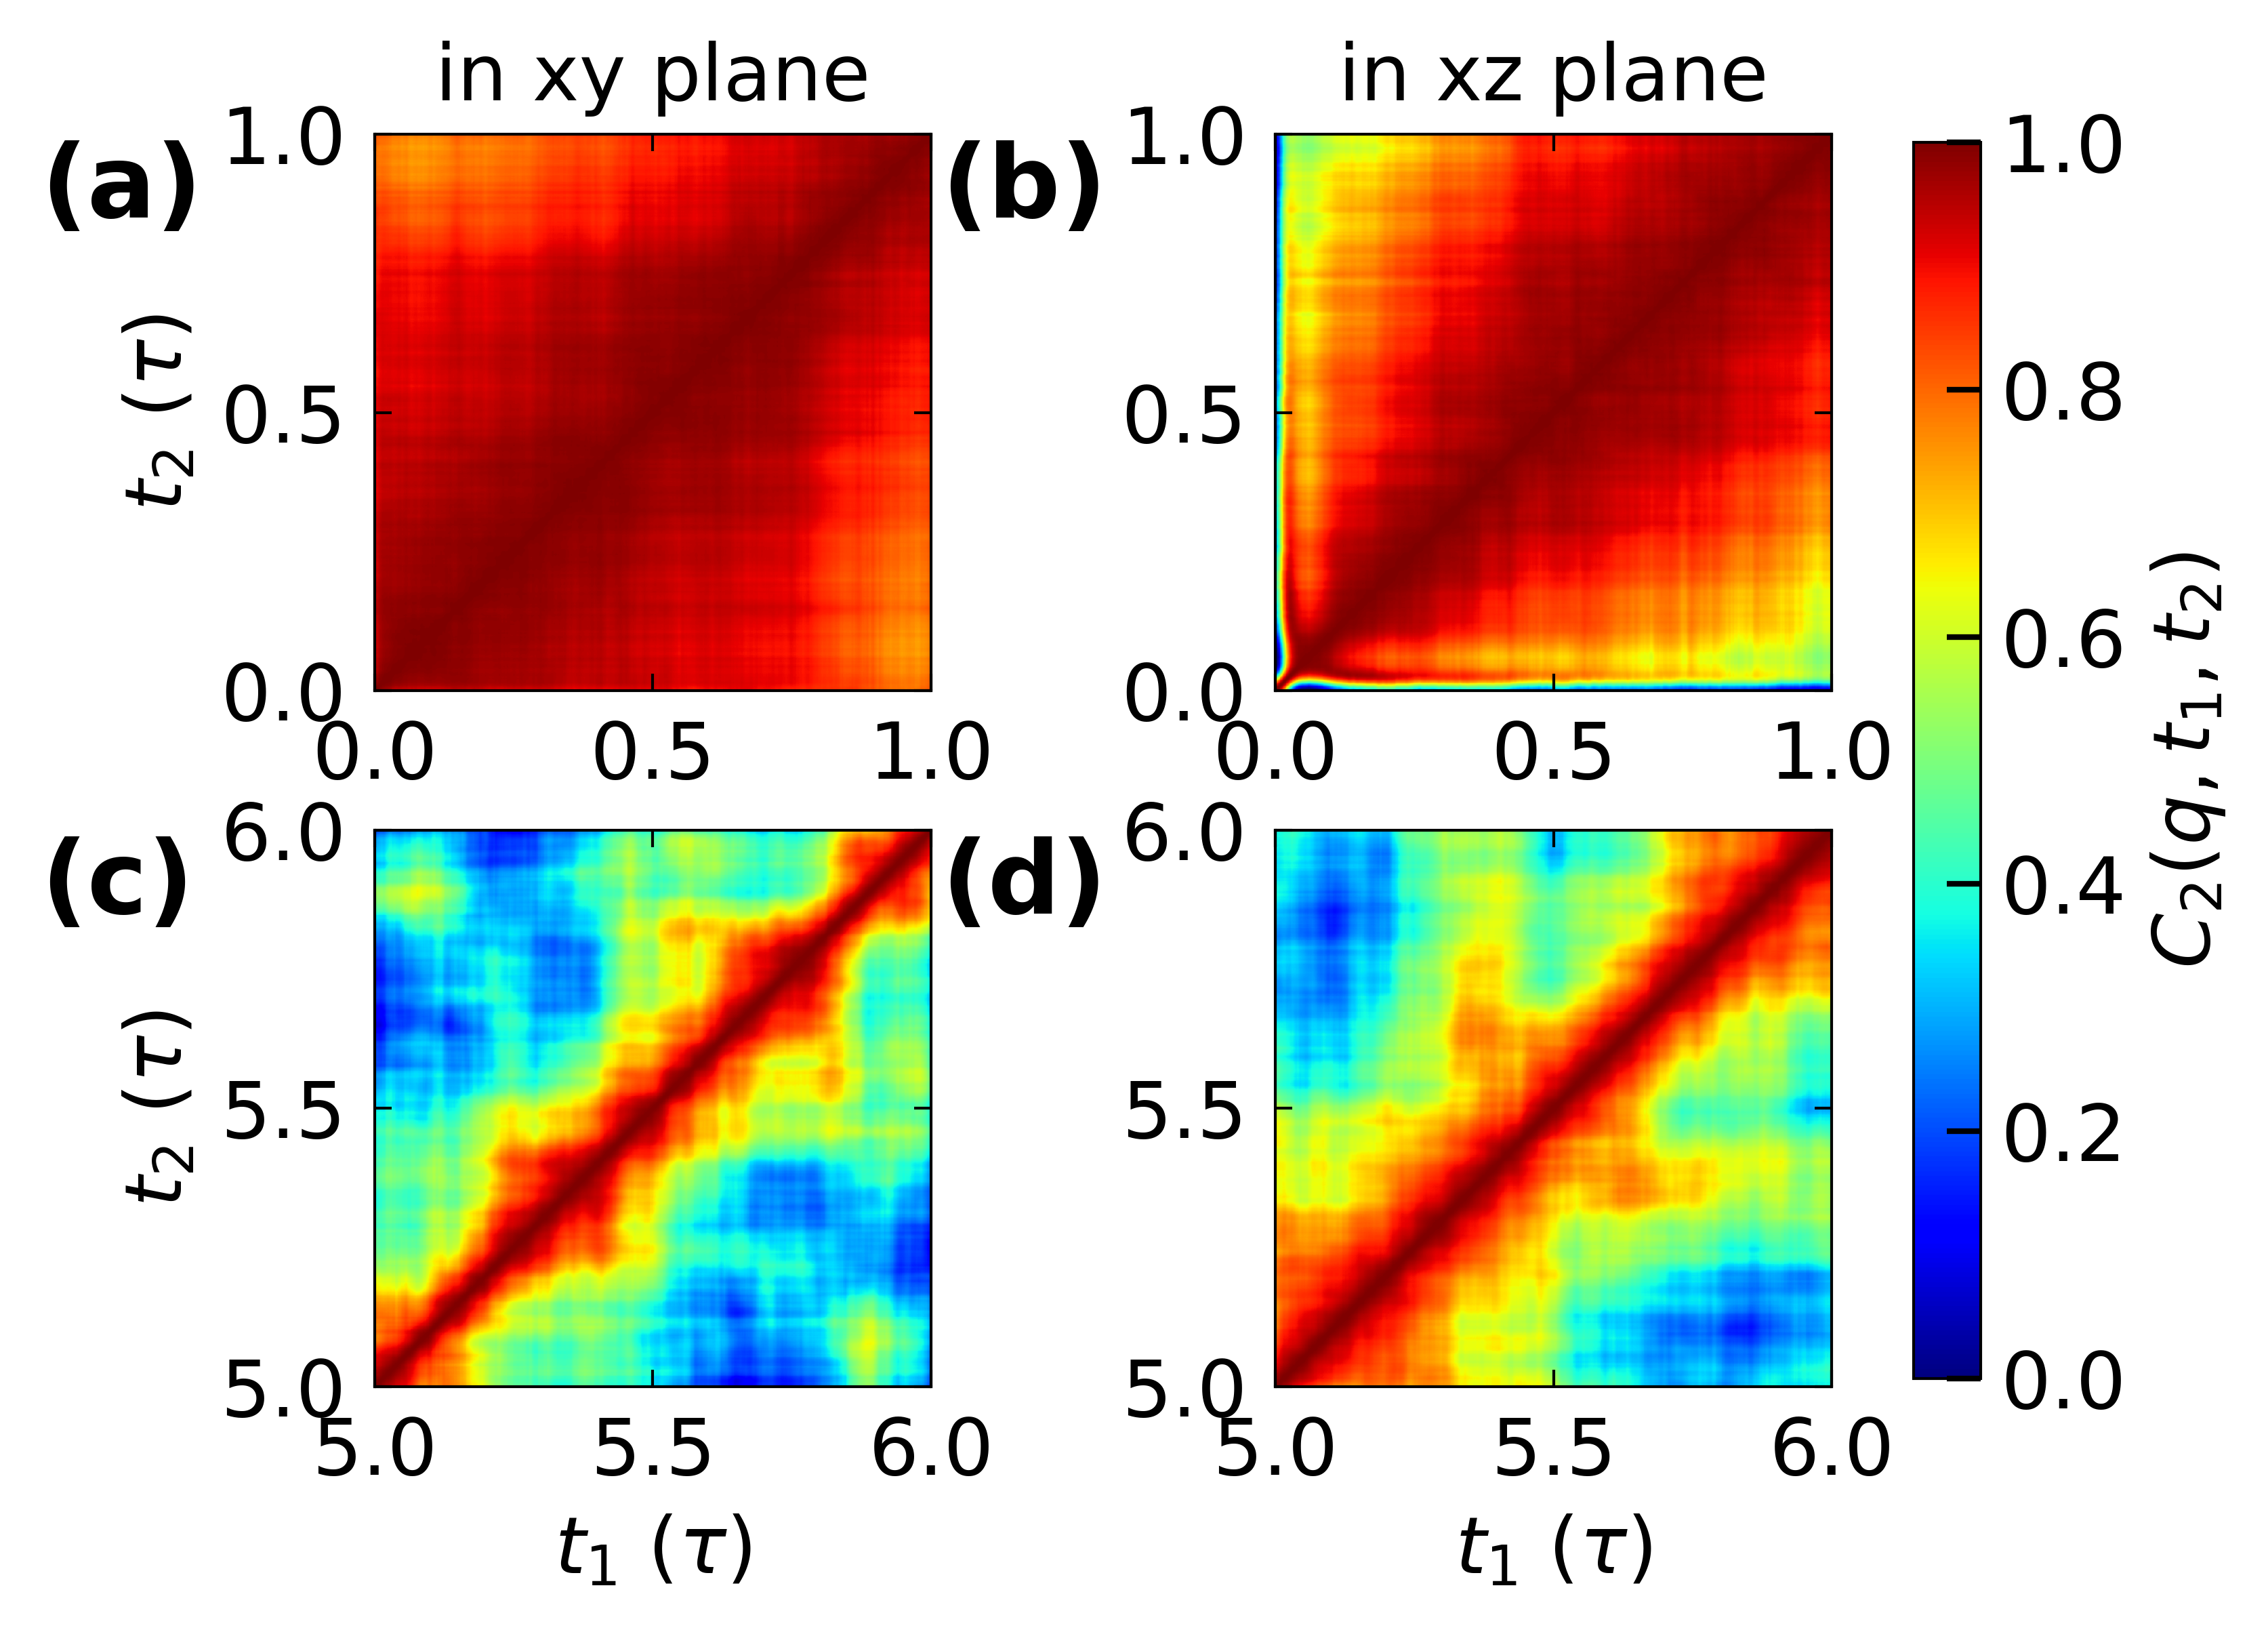

In [11]:
# fig ttc
dir_ttc = "./data/ttc/" # rate=1.0

with plt.style.context('four'):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5.5,4))

    # xy: t0 (y); xz: t0 (z)
    # xy: t5 (y); xz: t5 (z)

    # first
    c2_ttc_xy2 = np.load(os.path.join(dir_ttc, "0-1-1000/c2_ttc_xy2.npy"))
    im1 = axes[0,0].imshow(c2_ttc_xy2[0,:,:], 
                     interpolation='none', #'gaussian', 
                     origin='lower',
                     extent=[0, 1, 0, 1], 
                     cmap='jet')

    # second
    c2_ttc_xz2 = np.load(os.path.join(dir_ttc, "0-1-1000/c2_ttc_xz2.npy"))
    im2 = axes[0,1].imshow(c2_ttc_xz2[0,:,:], 
                     interpolation='none', #'gaussian', 
                     origin='lower',
                     extent=[0, 1, 0, 1], 
                     cmap='jet')
    
    # third
    c2_ttc_xy2 = np.load(os.path.join(dir_ttc, "5000-1-6000/c2_ttc_xy2.npy"))
    im3 = axes[1,0].imshow(c2_ttc_xy2[0,:,:], 
                     interpolation='none', #'gaussian', 
                     origin='lower',
                     extent=[5, 6, 5, 6], 
                     cmap='jet')

    # fourth
    c2_ttc_xz2 = np.load(os.path.join(dir_ttc, "5000-1-6000/c2_ttc_xz2.npy"))
    im4 = axes[1,1].imshow(c2_ttc_xz2[0,:,:], 
                     interpolation='none', #'gaussian', 
                     origin='lower',
                     extent=[5, 6, 5, 6], 
                     cmap='jet')
    
    # thickness
    tn = 0.5
    for ax, im in zip(axes.flatten(), [im1,im2,im3,im4]):
        im.set_clim(vmin=0.0, vmax=1.0)
        # cbar = fig.colorbar(im,ax=ax)

        ax.tick_params(axis='both', which='major', width=tn, length=3, pad=5) # Set major ticks width
        # ax.tick_params(axis='both', which='minor', width=1, length=3) # Set minor ticks width (optional)
        ax.spines['top'].set_linewidth(tn)
        ax.spines['bottom'].set_linewidth(tn)
        ax.spines['left'].set_linewidth(tn)
        ax.spines['right'].set_linewidth(tn)

    # colorbar
    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.85, 0.115, 0.03, 0.76])
    cbar = fig.colorbar(im4, 
                        cax=cbar_ax, 
                        # ax=axes[0].ravel().tolist(),
                        # shrink=0.65,
                        format='%.1f')
    cbar.outline.set_linewidth(0.5)
    cbar.ax.tick_params(length=6)
    cbar.set_label(r'$C_2(q, t_1, t_2)$') # Set colorbar label and its font size

    # text
    figNOtype = "bold"
    for ax, ax_label in zip(axes.flatten(), ["(a)","(b)","(c)","(d)"]):
        ax.text(-0.6,0.85,ax_label,fontweight=figNOtype, transform=ax.transAxes)

    # title
    axes[0,0].set_title("in xy plane", fontsize=14)
    axes[0,1].set_title("in xz plane", fontsize=14)

    # label
    for ax in axes[1,:]:
        ax.set_xlabel(r"$t_1$ " + r"$(\tau)$")    
    for ax in axes[:,0]:
        ax.set_ylabel(r"$t_2$ " + r"$(\tau)$")

    # plt.tight_layout()
    plt.subplots_adjust(hspace=0.25, wspace=0.25)
    plt.savefig("figs/ttc.png")
    plt.show()